In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
np.random.seed(42)
n = 750
genres = ['Action', 'Comedy', 'Drama', 'Sci-Fi', 'Thriller', 'Romance']

df = pd.DataFrame({
    'UserID': range(1001, 1001 + n),
    'Age': np.random.randint(18, 65, n),
    'Gender': np.random.choice(['Male', 'Female'], n),
    'SubscriptionType': np.random.choice(['Basic', 'Premium', 'VIP'], n, p=[0.5, 0.35, 0.15]),
    'WatchHoursPerWeek': np.round(np.random.uniform(1, 40, n), 1),
    'DevicesUsed': np.random.randint(1, 6, n),
    'FavoriteGenre': np.random.choice(genres, n),
    'AdClicks': np.random.randint(0, 50, n),
    'MonthlySpend': np.round(np.random.uniform(199, 999, n), 2),
    'SubscriptionRenewed': np.random.choice(['Yes', 'No'], n, p=[0.65, 0.35])
})
print("Dataset created:", df.shape)

Dataset created: (750, 10)


In [3]:
# Q1
print("Q1. First 5 records:")
print(df.head())

# Q2
print("\nQ2. Rows and Columns:", df.shape)

# Q3
print("\nQ3. Column Names:", df.columns.tolist())

# Q4
num = df.select_dtypes(include=['int64','float64']).columns.tolist()
cat = df.select_dtypes(include=['object']).columns.tolist()
print("\nQ4. Numerical:", num)
print("Categorical:", cat)

# Q5
print("\nQ5. Missing Values:")
print(df.isnull().sum())

Q1. First 5 records:
   UserID  Age  Gender SubscriptionType  WatchHoursPerWeek  DevicesUsed  \
0    1001   56  Female            Basic               21.1            5   
1    1002   46    Male          Premium               36.9            2   
2    1003   32    Male            Basic               20.4            5   
3    1004   60    Male          Premium               39.7            3   
4    1005   25  Female            Basic               34.2            3   

  FavoriteGenre  AdClicks  MonthlySpend SubscriptionRenewed  
0         Drama        39        269.07                  No  
1         Drama        42        270.93                 Yes  
2        Comedy        21        353.60                 Yes  
3        Action        19        239.45                 Yes  
4        Sci-Fi         7        700.17                  No  

Q2. Rows and Columns: (750, 10)

Q3. Column Names: ['UserID', 'Age', 'Gender', 'SubscriptionType', 'WatchHoursPerWeek', 'DevicesUsed', 'FavoriteGenre', 'Ad

Q6. Average Age: 41.22
Q7. Avg Watch Hours/Week: 20.45
Q8. Avg Monthly Spend: ₹ 585.21

Q9. Users per Subscription Type:
SubscriptionType
Basic      364
Premium    266
VIP        120
Name: count, dtype: int64


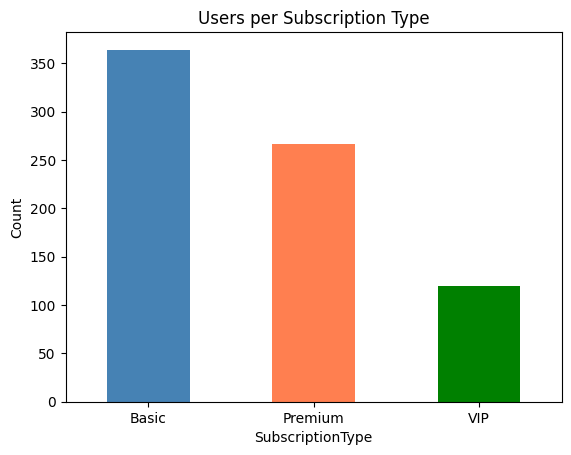


Q10. Renewal Percentage: 64.27%


In [4]:
# Q6
print("Q6. Average Age:", round(df['Age'].mean(), 2))

# Q7
print("Q7. Avg Watch Hours/Week:", round(df['WatchHoursPerWeek'].mean(), 2))

# Q8
print("Q8. Avg Monthly Spend: ₹", round(df['MonthlySpend'].mean(), 2))

# Q9
print("\nQ9. Users per Subscription Type:")
print(df['SubscriptionType'].value_counts())
df['SubscriptionType'].value_counts().plot(kind='bar', color=['steelblue','coral','green'])
plt.title('Users per Subscription Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

# Q10
pct = (df['SubscriptionRenewed'].value_counts()['Yes'] / len(df)) * 100
print(f"\nQ10. Renewal Percentage: {pct:.2f}%")

In [5]:
# Q11 - Encode categorical columns
df_enc = df.copy()
le = LabelEncoder()
for col in ['Gender', 'SubscriptionType', 'FavoriteGenre', 'SubscriptionRenewed']:
    df_enc[col] = le.fit_transform(df_enc[col])
print("Q11. Encoded Data:")
print(df_enc.head())

# Q12 - Feature set and target
X = df_enc[['Age','Gender','SubscriptionType','WatchHoursPerWeek','DevicesUsed','FavoriteGenre','AdClicks','MonthlySpend']]
y = df_enc['SubscriptionRenewed']
print("\nQ12. X shape:", X.shape, "| y shape:", y.shape)

# Q13 - Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print("\nQ13. Train:", X_train.shape[0], "| Test:", X_test.shape[0])

Q11. Encoded Data:
   UserID  Age  Gender  SubscriptionType  WatchHoursPerWeek  DevicesUsed  \
0    1001   56       0                 0               21.1            5   
1    1002   46       1                 1               36.9            2   
2    1003   32       1                 0               20.4            5   
3    1004   60       1                 1               39.7            3   
4    1005   25       0                 0               34.2            3   

   FavoriteGenre  AdClicks  MonthlySpend  SubscriptionRenewed  
0              2        39        269.07                    0  
1              2        42        270.93                    1  
2              1        21        353.60                    1  
3              0        19        239.45                    1  
4              4         7        700.17                    0  

Q12. X shape: (750, 8) | y shape: (750,)

Q13. Train: 600 | Test: 150


Q14. Decision Tree trained!
Q15. Decision Tree Accuracy: 58.67%


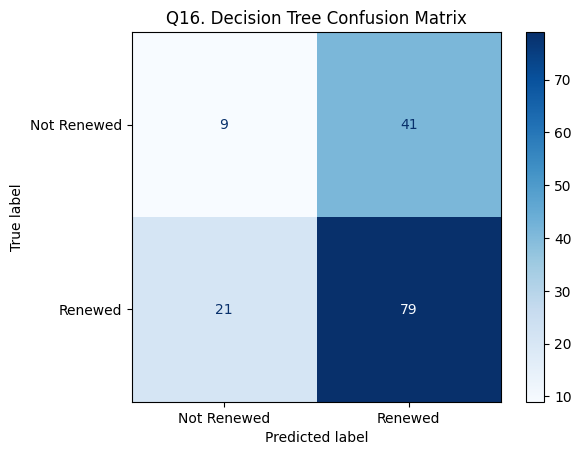

TN: 9 | FP: 41
FN: 21 | TP: 79


In [6]:
# Q14 - Train Decision Tree
dt = DecisionTreeClassifier(random_state=42, max_depth=5)
dt.fit(X_train, y_train)
print("Q14. Decision Tree trained!")

# Q15 - Accuracy
y_pred_dt = dt.predict(X_test)
print(f"Q15. Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt)*100:.2f}%")

# Q16 - Confusion Matrix
cm = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm, display_labels=['Not Renewed','Renewed']).plot(cmap='Blues')
plt.title('Q16. Decision Tree Confusion Matrix')
plt.show()
print("TN:", cm[0][0], "| FP:", cm[0][1])
print("FN:", cm[1][0], "| TP:", cm[1][1])

Q17. KNN Accuracy: 59.33%

Q18. Decision Tree: 58.67% | KNN: 59.33%


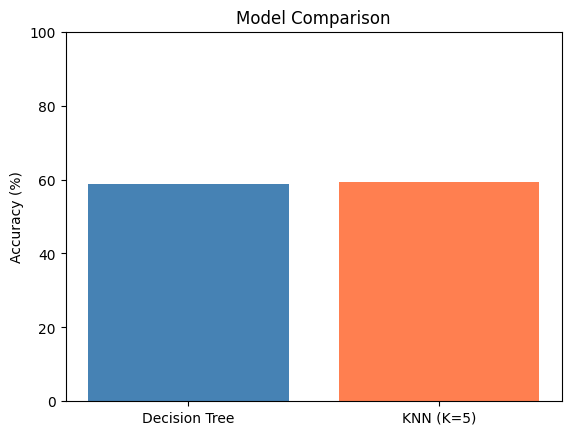

In [7]:
# Q17 - KNN K=5
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)
knn_acc = accuracy_score(y_test, y_pred_knn)
print(f"Q17. KNN Accuracy: {knn_acc*100:.2f}%")

# Q18 - Comparison
dt_acc = accuracy_score(y_test, y_pred_dt)
print(f"\nQ18. Decision Tree: {dt_acc*100:.2f}% | KNN: {knn_acc*100:.2f}%")
plt.bar(['Decision Tree', 'KNN (K=5)'], [dt_acc*100, knn_acc*100], color=['steelblue','coral'])
plt.ylabel('Accuracy (%)')
plt.title('Model Comparison')
plt.ylim(0, 100)
plt.show()

Q19. MSE: 50571.42
R² Score: -0.0175


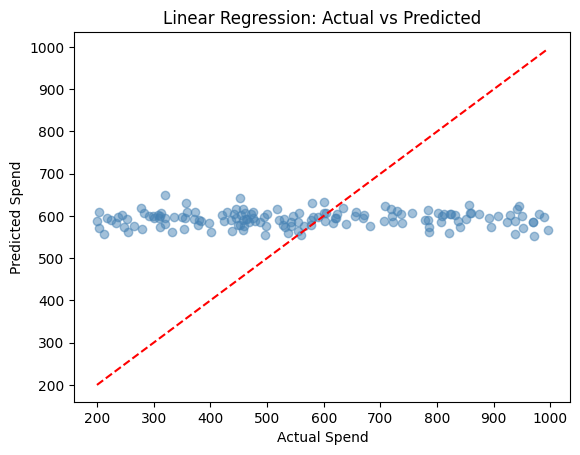


Q20. Predicted Monthly Spend for new user: ₹619.30
A 28-yr-old Premium female user watching 15 hrs/week is predicted to spend ₹619.30/month.


In [8]:
# Q19 - Linear Regression for MonthlySpend
X_reg = df_enc[['Age','Gender','SubscriptionType','WatchHoursPerWeek','DevicesUsed','FavoriteGenre','AdClicks']]
y_reg = df_enc['MonthlySpend']

X_tr, X_te, y_tr, y_te = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)
lr = LinearRegression()
lr.fit(X_tr, y_tr)
y_pred_lr = lr.predict(X_te)

print(f"Q19. MSE: {mean_squared_error(y_te, y_pred_lr):.2f}")
print(f"R² Score: {r2_score(y_te, y_pred_lr):.4f}")

plt.scatter(y_te, y_pred_lr, alpha=0.5, color='steelblue')
plt.plot([y_te.min(), y_te.max()], [y_te.min(), y_te.max()], 'r--')
plt.xlabel('Actual Spend')
plt.ylabel('Predicted Spend')
plt.title('Linear Regression: Actual vs Predicted')
plt.show()

# Q20 - Predict for new user
new_user = pd.DataFrame([{
    'Age': 28, 'Gender': 0, 'SubscriptionType': 1,
    'WatchHoursPerWeek': 15, 'DevicesUsed': 2,
    'FavoriteGenre': 1, 'AdClicks': 10
}])
pred = lr.predict(new_user)[0]
print(f"\nQ20. Predicted Monthly Spend for new user: ₹{pred:.2f}")
print("A 28-yr-old Premium female user watching 15 hrs/week is predicted to spend ₹{:.2f}/month.".format(pred))